# My First SewerTris Project Workflow

This notebook implements the first SewerTris example using the project-oriented API. Instead of manually passing every path between cells, a `SewerTrisProject` object owns the output directory, standard filenames, JSON metadata, and scenario folders. The physical network is generated once, then dynamic SWMM input scenarios can be rerun without rebuilding the city, DEM, and sewer network.

The notebook follows the twelve SewerTris model implementation steps:

1. Urban Domain Definition: Defines the spatial modeling boundary using a vector polygon or raster mask and establishes the sewer outlet location.

2. Tetris Block Definition: Specifies modular tetromino building blocks (I, O, T, S, Z, J, L, BO shapes) that form the geometric basis of the synthetic urban layout.

3. Stochastic Tetris Completion: Populates the domain using randomized block placement to generate heterogeneous but coherent urban configurations.

4. Road Network Extraction: Derives a synthetic road network from block boundaries, ensuring topological consistency with urban structure.

5. Land-Use Assignment: Assigns residential, commercial, industrial, public, and recreational land uses using rule-based or user-defined allocation strategies.

6. Synthetic DEM Generation: Creates a hydraulically consistent Digital Elevation Model (DEM) enforcing global drainage toward the outlet.

7. Sewer Network Generation: Constructs a gravity-driven, tree-structured sewer network aligned with roads and embedded within the DEM.

8. Sewer Flow Predesign: Computes baseline peak discharges combining Dry-Weather Flow (DWF), Groundwater Infiltration (GWI), and Rainfall-Derived Inflow & Infiltration (RDII).

9. Pipe Sizing and Hydraulic Properties: Assigns pipe diameters, roughness, and invert elevations using Manning-based design principles.

10. Dynamic Flow Input Definition: Specifies temporally resolved DWF, GWI, and RDII inputs, including rainfall forcing and spatial heterogeneity options.

11. EPA-SWMM Simulation: Performs unsteady hydraulic routing and enables component tagging (RAIN and DRY) for flow separation analysis.

12. Flow Output Decomposition: Extracts and decomposes total flows into DWF, RDII, and residual GWI components for benchmarking and diagnostics.

## Setup: Import Libraries and Create a Project

The notebook imports only the packages used directly in the cells. The modeling logic itself lives inside the refactored `sewertris` package.

In [15]:
from pathlib import Path
import sys

import geopandas as gpd
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "Examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris as st

min_width = 100  # meters
project = st.SewerTrisProject(
    EXAMPLES_DIR / "output_example_1_project",
    cell_size_m=min_width,
    name="My First SewerTris Project",
)
project.save()
print(f"Project metadata: {project.project_file}")

Project metadata: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewertris_project.json


## 1. Urban Domain Definition

The project stores the domain mask and records this step in `sewertris_project.json`. This example uses a manual raster-style mask; a shapefile workflow can use `project.define_domain(shapefile_path=..., cell_size_m=...)` instead.

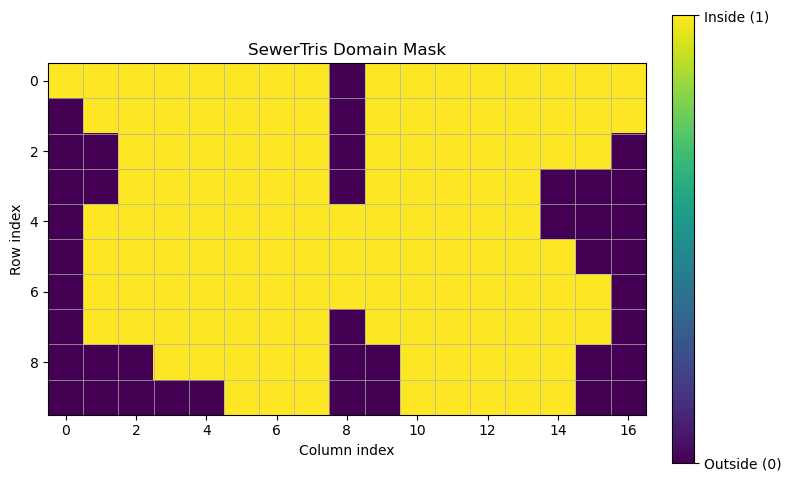

In [16]:
domain_mask = np.array([
    [0,0,0,0,0,1,1,1,0,0,1,1,1,1,1,0,0],
    [0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
    [0,0,1,1,1,1,1,1,0,1,1,1,1,1,0,0,0],
    [0,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
])

project.define_domain(domain_mask=domain_mask, cell_size_m=min_width)
st.plot_domain_mask(np.fliplr(np.rot90(domain_mask, 2)), title="SewerTris Domain Mask")

## 2. Tetris Block Definition

Tetromino shapes and colors are stored in the project state. The project metadata records the available block keys.

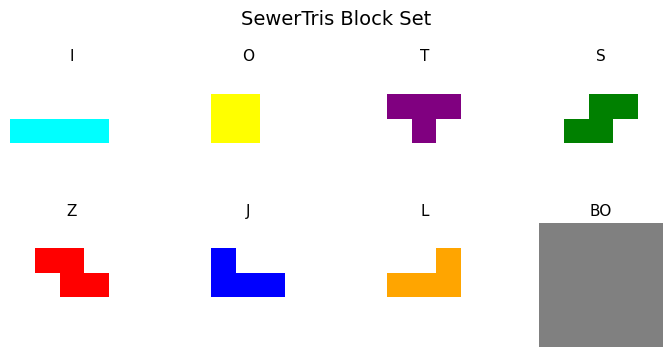

In [17]:
tetrominoes = {
    'I': [np.array([[1,1,1,1]]), np.array([[1],[1],[1],[1]])],
    'O': [np.array([[1,1],[1,1]])],
    'T': [np.array([[1,1,1],[0,1,0]]), np.array([[0,1],[1,1],[0,1]]), np.array([[0,1,0],[1,1,1]]), np.array([[1,0],[1,1],[1,0]])],
    'S': [np.array([[0,1,1],[1,1,0]]), np.array([[1,0],[1,1],[0,1]])],
    'Z': [np.array([[1,1,0],[0,1,1]]), np.array([[0,1],[1,1],[1,0]])],
    'J': [np.array([[1,0,0],[1,1,1]]), np.array([[1,1],[1,0],[1,0]]), np.array([[1,1,1],[0,0,1]]), np.array([[0,1],[0,1],[1,1]])],
    'L': [np.array([[0,0,1],[1,1,1]]), np.array([[1,0],[1,0],[1,1]]), np.array([[1,1,1],[1,0,0]]), np.array([[1,1],[0,1],[0,1]])],
    'BO': [np.array([[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]])],
}

tetromino_colors = {
    'I': 'cyan',
    'O': 'yellow',
    'T': 'purple',
    'S': 'green',
    'Z': 'red',
    'J': 'blue',
    'L': 'orange',
    'BO': 'grey',
}

project.define_tetrominoes(tetrominoes, tetromino_colors)
st.plot_tetromino_set(tetrominoes, tetromino_colors, ncols=4)

## 3. Stochastic Tetris Completion

The project fills the domain, exports the layout to `project.layout_blocks_path`, and records the output path in the project JSON.

✅ Exported 51 figures to /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/city_layout.gpkg
Total blocks: 52
Layout blocks: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/city_layout.gpkg


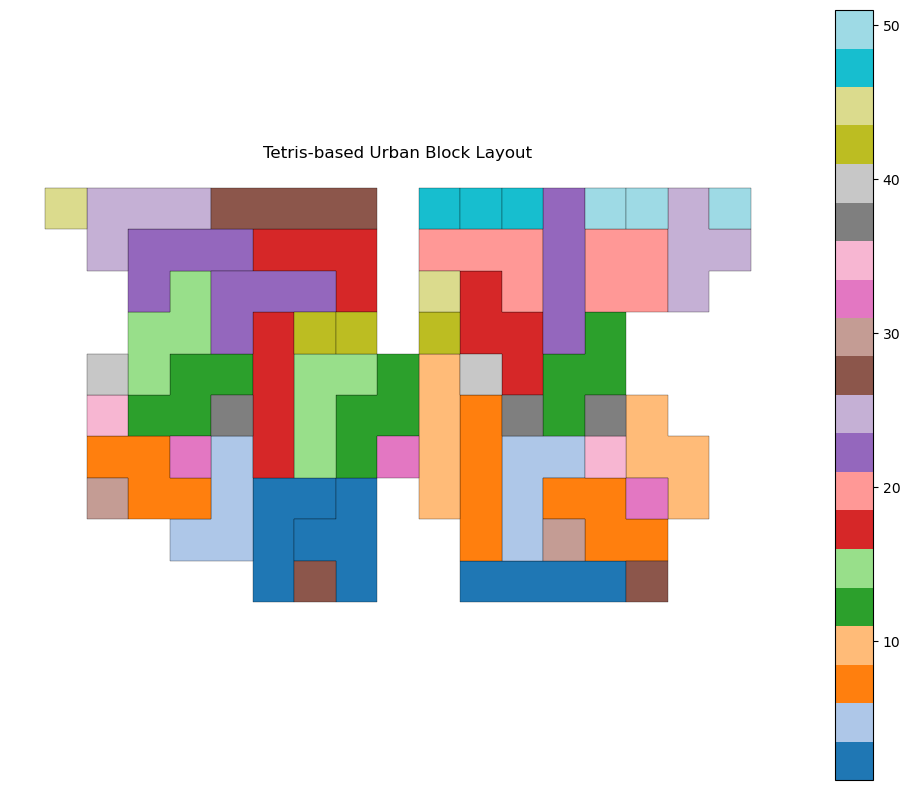

In [18]:
layout_seed = 1000

filled_board, id_type_map, block_id = project.complete_tetris_layout(
    crs="EPSG:3857",
    flip_y=True,
    seed=layout_seed,
)

print("Total blocks:", len(np.unique(filled_board)))
print("Layout blocks:", project.layout_blocks_path)
st.plot_filled_board_shapefile(project.layout_blocks_path)

## 4. Road Network Extraction

The project derives road centerlines and polygons from the generated layout and stores them at standard project paths.

[OK] Boundary lines written to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/road_boundary_lines.gpkg
[OK] Outer shell polygon(s) written to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/road_outer_shell.gpkg
Road centerlines: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/road_centerlines.gpkg
Road polygons: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/road_polygons.gpkg


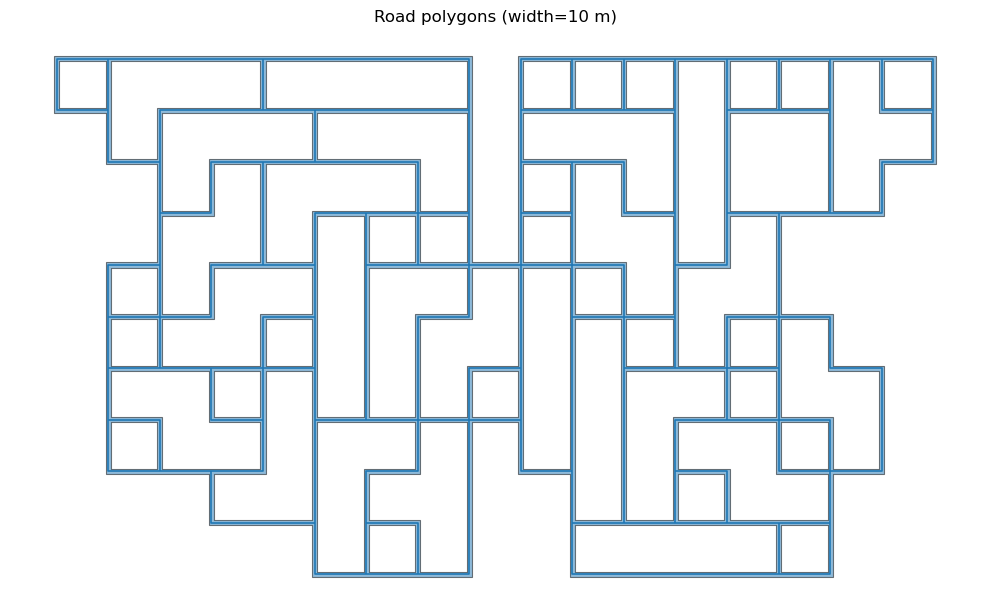

In [19]:
road_width = 10  # meters
road_lines, road_buffer, crs = project.generate_roads(
    road_width=road_width,
    simplify_tol=0.5,
)
project.extract_road_boundaries()

print("Road centerlines:", project.road_centerlines_path)
print("Road polygons:", project.road_polygons_path)
st.plot_roads(
    road_lines=road_lines,
    road_buffer=road_buffer,
    crs=crs,
    title=f"Road polygons (width={road_width} m)",
)

## 5. Land-Use Assignment

The project cuts blocks by the road network, assigns compact land-use categories, and writes the final block layer to `project.blocks_path`.

✅ Exported to /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/city_blocks.gpkg
Land-use blocks: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/city_blocks.gpkg


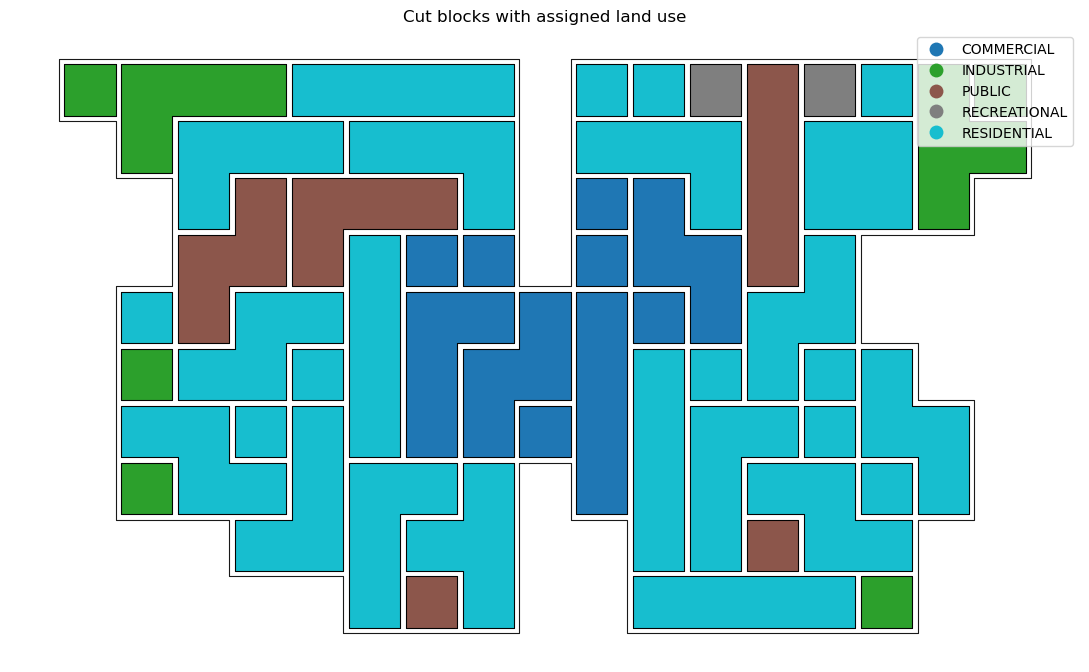

In [20]:
blocks_gdf = project.assign_land_use()
roads_gdf = gpd.read_file(project.road_polygons_path)
if roads_gdf.crs != blocks_gdf.crs:
    roads_gdf = roads_gdf.to_crs(blocks_gdf.crs)

print("Land-use blocks:", project.blocks_path)
st.plot_blocks_landuse(
    blocks_gdf=blocks_gdf,
    roads_gdf=roads_gdf,
    landuse_col="land_use",
    title="Cut blocks with assigned land use",
    savepath=project.path("blocks_landuse.png"),
)

## 6. Synthetic DEM Generation

The project builds a hydraulically consistent DEM using the extracted road shell as the boundary and saves it to `project.dem_path`.

[OK] Boundary lines written to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/road_boundary_lines.gpkg
[OK] Outer shell polygon(s) written to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/road_outer_shell.gpkg
Original boundary CRS: EPSG:3857
Original roads CRS: EPSG:3857

Boundary extent:
X range: -5.00 to 1705.00
Y range: -5.00 to 1005.00
Boundary CRS: EPSG:3857
Boundary bounds: [  -5.   -5. 1705. 1005.]
Grid shape: (122, 192)
Grid extent:
  X: -110.00 to 1810.00
  Y: -110.00 to 1110.00
Creating mask...
Processing row 0 of 122
Processing row 100 of 122
Outlet cell: (57, 20)
Computing geodesic distances...
Processing roads...


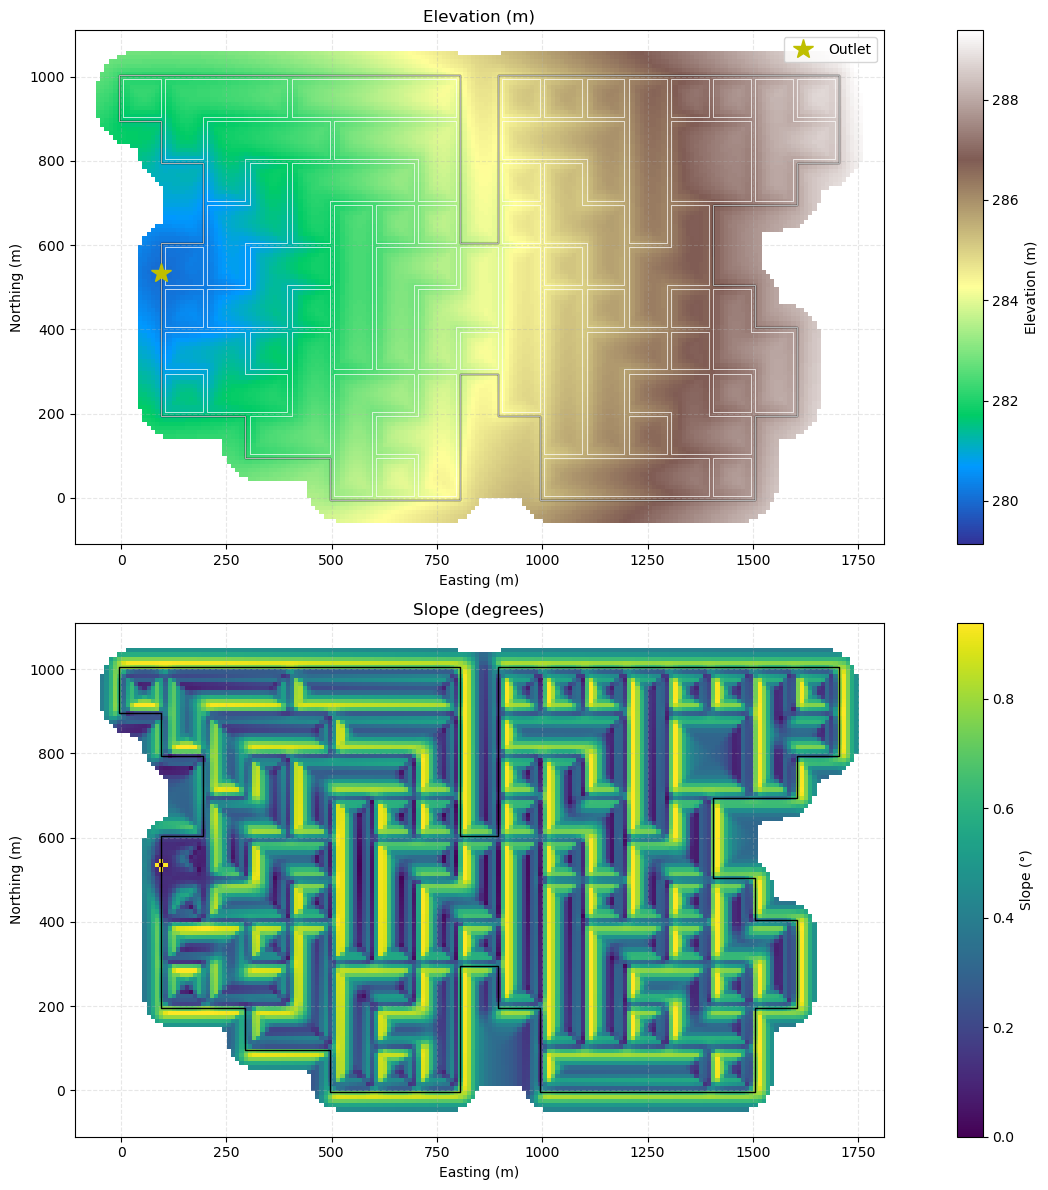


Terrain Statistics:
Elevation range: 279.14m - 289.38m
Mean elevation: 284.42m
Mean slope: 0.48°
Max slope: 2.58°

Drainage Statistics:
Points with proper drainage: 17278.0 out of 19926 (86.7%)
DEM: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/generated_topography.tif


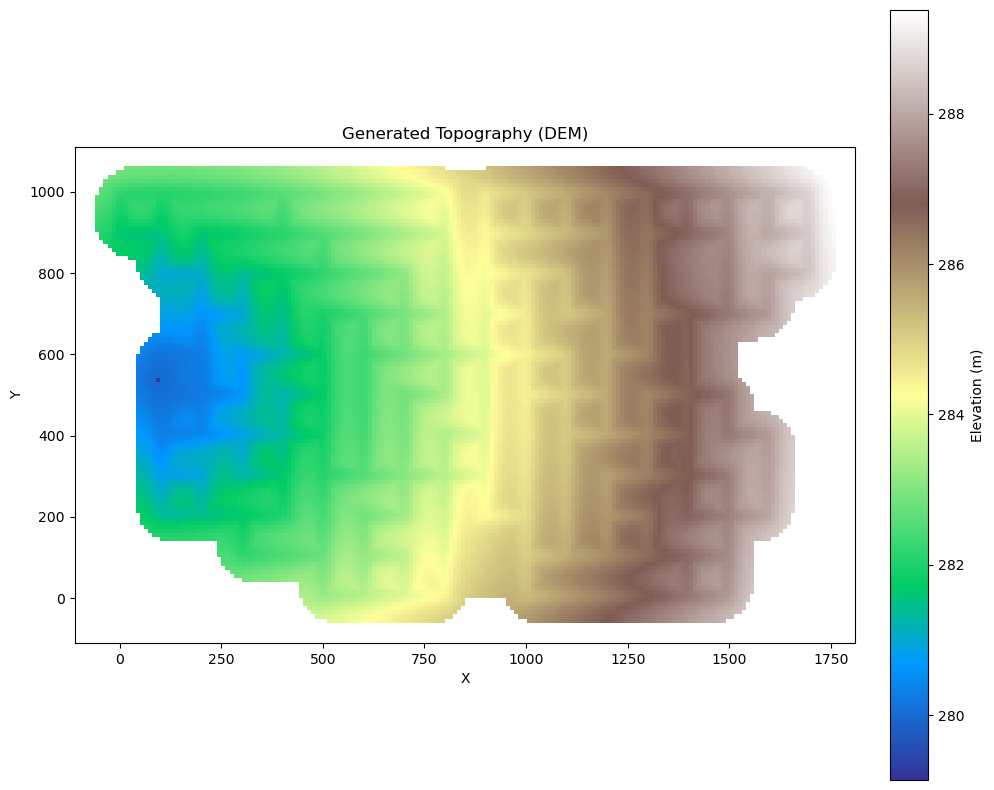

In [21]:
config = st.TopographyConfig(
    min_elevation=280,
    max_elevation=290,
    cell_size=10,
    outlet_direction='W',
    smoothing_factor=1,
)

elevation, xx, yy, mask = project.generate_topography(config=config)
print("DEM:", project.dem_path)
st.plot_dem_tif(project.dem_path, title="Generated Topography (DEM)", hillshade=False)

## 7. Sewer Network Generation

The project extracts manholes, generates main/secondary/tertiary gravity pipes, exports sewer network shapefiles, and then embeds the network into the DEM to enforce positive slopes.

✅ Extracted 135 manholes from road centerlines.
✅ Manholes exported to /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/manholes.gpkg

Path Statistics:
Head: MH127  →  Target: MH086
Segments: 23
Total length: 2300.0 m
Total drop: 8.73 m
Avg slope: 0.379%
⚠️ Some manholes could not be connected while preserving constraints.
✅ Generated 61 secondary pipes.
✅ Cleaned: 0 secondary pipes removed.
📊 V2 initial missing outlet pipes: 50
V2 iteration 1: start=MH009, status=committed, chain_len=2, cost=241.52, remaining=48
V2 iteration 2: start=MH033, status=committed, chain_len=1, cost=117.36, remaining=47
V2 iteration 3: start=MH041, status=committed, chain_len=3, cost=469.21, remaining=44
V2 iteration 4: start=MH061, status=committed, chain_len=2, cost=200.00, remaining=42
V2 iteration 5: start=MH076, status=committed, chain_len=5, cost=658.05, remaining=37
V2 iteration 6: start=MH077, status=committed, chain_len=2, cost=202.79, remaining=35
V2 iteration 7: start=MH085

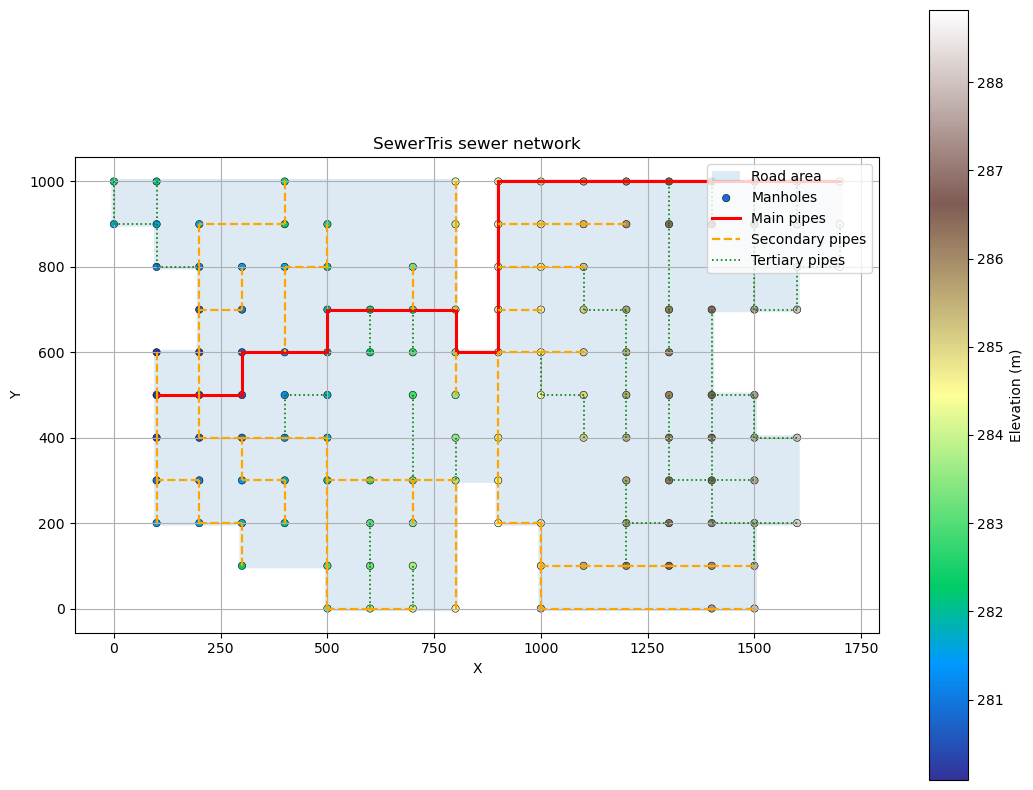

⚠️ Raster check: 82 pipes have a local slope < Smin (e.g., idx=121, slope=-0.000332).
Updated elevations for 135/135 manholes. Wrote: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/manholes.gpkg


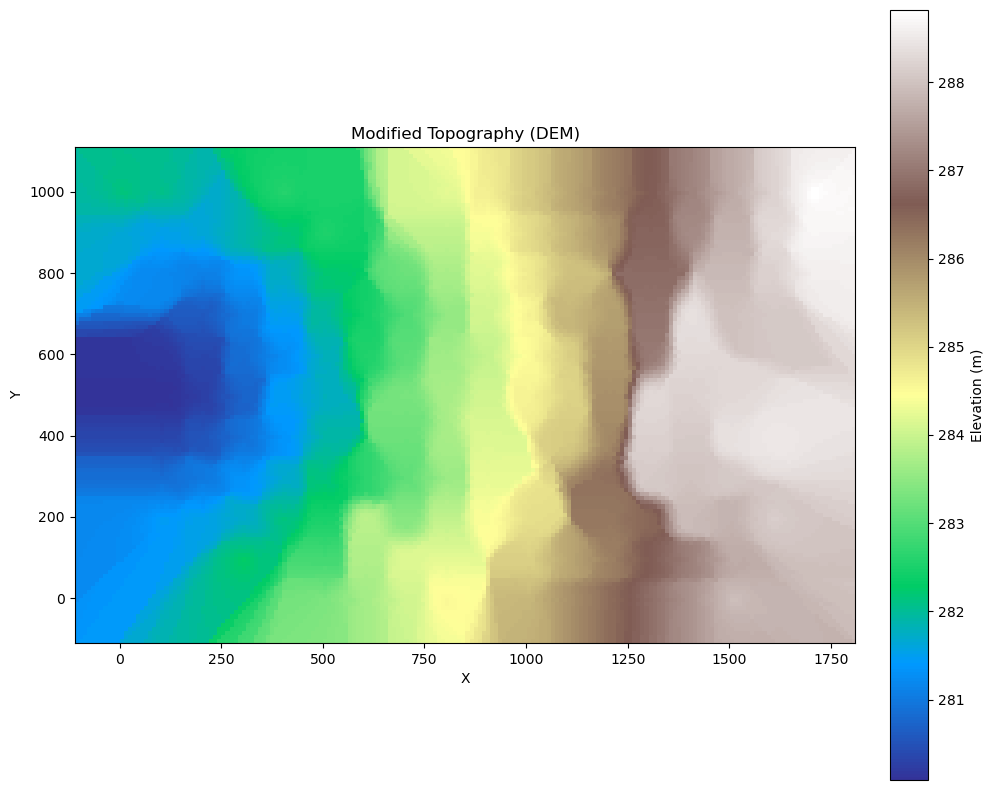

In [22]:
gdf_pipes = project.generate_sewer_network_V2(
    road_width=road_width,
    block_size=min_width * 2,
    main_slope_tolerance=-0.01,
    secondary_slope_tolerance=0.0,
    prefer_slope=0.5,
    tertiary_block_size=min_width * 10,
    neighbor_radius_factor=1.5,
    tertiary_min_pipe_length=1e-3,
    point_on_line_tol=0.01,
    tertiary_adverse_slope_weight=200.0,
    tertiary_mild_adverse_slope=-0.005,
    tertiary_moderate_adverse_slope=-0.01,
    tertiary_severe_adverse_multiplier=8.0,
)

print("Pipes:", project.pipes_path)
print("Manholes:", project.manholes_path)

st.plot_sewer_network_all(
    manholes=project.state["manholes"],
    main_pipes=project.state["main_path"],
    secondary_pipes=project.state["secondary_pipes"],
    tertiary_pipes=project.state["tertiary_pipes"],
    unresolved=project.state["tertiary_unconnected"],
    road_buffer=project.state["road_buffer"],
    title="SewerTris sewer network",
)

project.embed_sewer_network_in_dem(
    upstream_field="upstream_m",
    downstream_field="downstream",
    manhole_id_field="id",
    manhole_elev_field="elevation",
    type_field="type",
    tier_order=("main", "secondary", "tertiary"),
    Smin=0.001,
    densify_step_m=None,
    along_pipe_weight=2,
    idw_power=2.0,
    idw_k=12,
    idw_tile=1024,
    centerline_writeback=True,
    verify_on_raster=True,
)
st.plot_dem_tif(project.dem_path, title="Modified Topography (DEM)", hillshade=False)

## 8. Sewer Flow Predesign

The project delineates subcatchments, assigns baseflow, computes peak flow, accumulates GWI and RDII, and writes predesign flow fields to the pipe layer.

In [23]:
LAND_USE_INFO = {
    'RESIDENTIAL': {'density': 60, 'demand': 100},
    'COMMERCIAL': {'density': 50, 'demand': 60},
    'INDUSTRIAL': {'density': 25, 'demand': 150},
    'PUBLIC': {'density': 20, 'demand': 100},
    'RECREATIONAL': {'density': 10, 'demand': 40},
}

predesign_pipes = project.predesign_flows(
    land_use_info=LAND_USE_INFO,
    gwi_factor_ls_per_m=0.0002,
    rdii_factor_ls_per_m2=0.00002,
    target_crs_m="EPSG:3857",
)
print("Subcatchments:", project.subcatchments_path)
print("Predesign pipes:", project.pipes_path)

✅ Sub-catchments saved to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewer_subcatchments.gpkg
✅ Updated pipe file saved: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewer_pipes.gpkg
Subcatchments: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewer_subcatchments.gpkg
Predesign pipes: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewer_pipes.gpkg


## 9. Pipe Sizing and Hydraulic Properties

The project assigns pipe slopes, materials, diameters, roughness, and invert elevations, then preprocesses the pipe and manhole layers for SWMM export.

✅ Pipe slopes assigned and saved to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewer_pipes.gpkg
✅ Materials and diameters assigned and saved to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewer_pipes.gpkg
✅ Invert elevations assigned and saved to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewer_pipes.gpkg
✅ Pipes saved to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewer_pipes.gpkg
✅ Manholes saved to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/manholes.gpkg


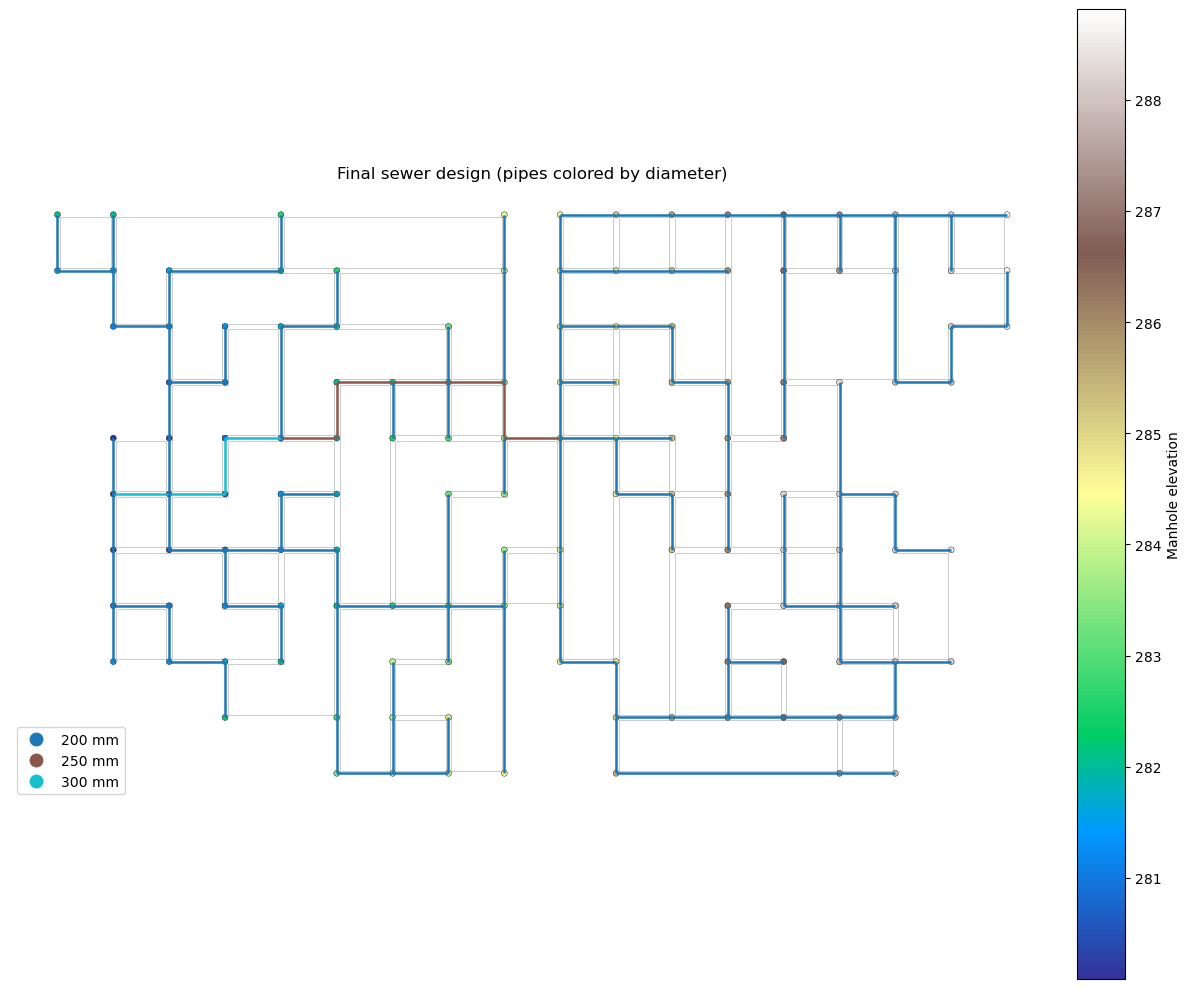

In [24]:
pipes_clean, manholes_clean = project.design_pipes(
    minimum_slope=0.005,
    material_fractions={"PVC": 0.6, "CONCRETE": 0.3, "HDPE": 0.1},
    n_by_material={"PVC": 0.011, "CONCRETE": 0.013, "HDPE": 0.012},
    standard_diameters_mm=[200, 250, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000],
    minimum_diameter_mm=200,
    min_cover=1.4,
    min_slope=0.005,
    manhole_drop=0.05,
)

st.plot_final_design_color_by_diameter(
    pipes_path=project.pipes_path,
    manholes_path=project.manholes_path,
    blocks_path=project.blocks_path,
    diameter_field="diameter_mm",
    manhole_color_field="elevation",
    linewidth=1.8,
)

## 10. Dynamic Flow Input Definition

The base SWMM model is exported once. A named scenario then copies that base input into its own folder and applies BWF/DWF patterns, GWI, and RDII rainfall inputs. After each input layer is added, the scenario is run and plotted, matching the function-by-function example while still preserving the project/scenario workflow.


✅ SWMM .inp file written to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewer_model.inp
✅ Updated [DWF] with patterns "1" "2" "3" "4"
✅ Rewrote [PATTERNS] with HOURLY, DAILY, MONTHLY, WEEKEND
   Output saved to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/scenarios/bwf_gwi_rdii/sewer_model.inp
BWF/DWF pattern scenario run


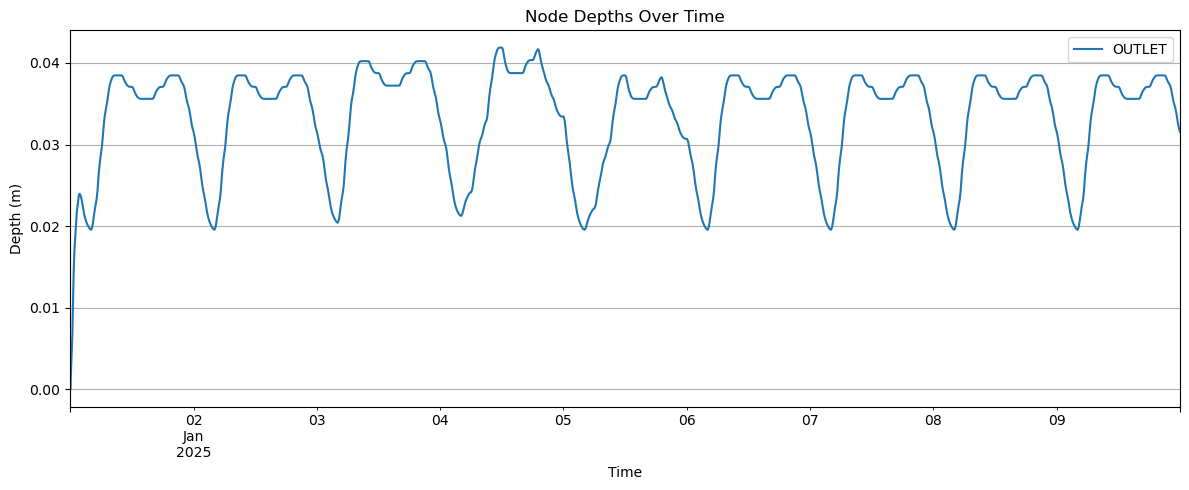

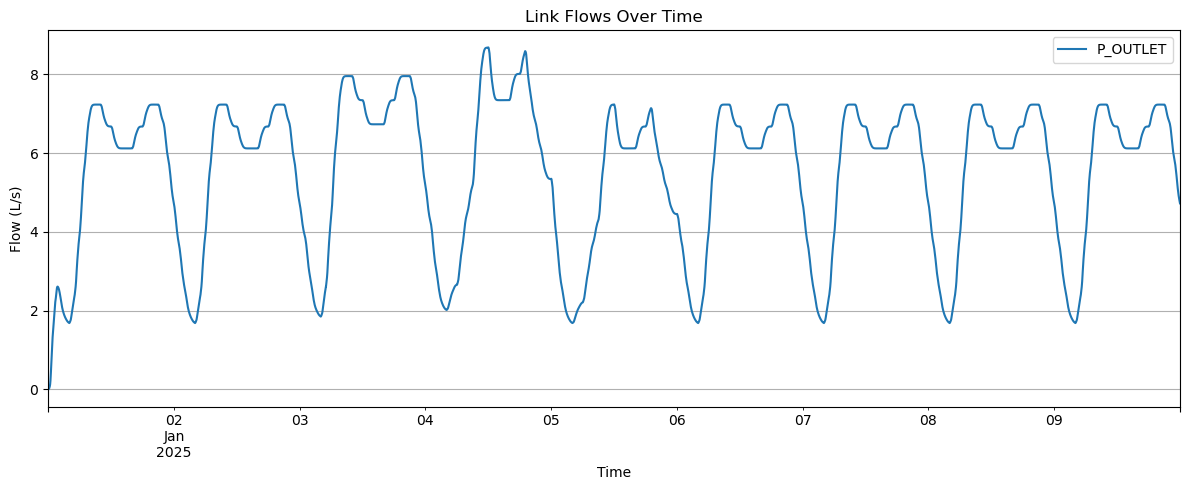

✅ INFLOWS section created using coefficient 0.0001. File saved to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/scenarios/bwf_gwi_rdii/sewer_model.inp


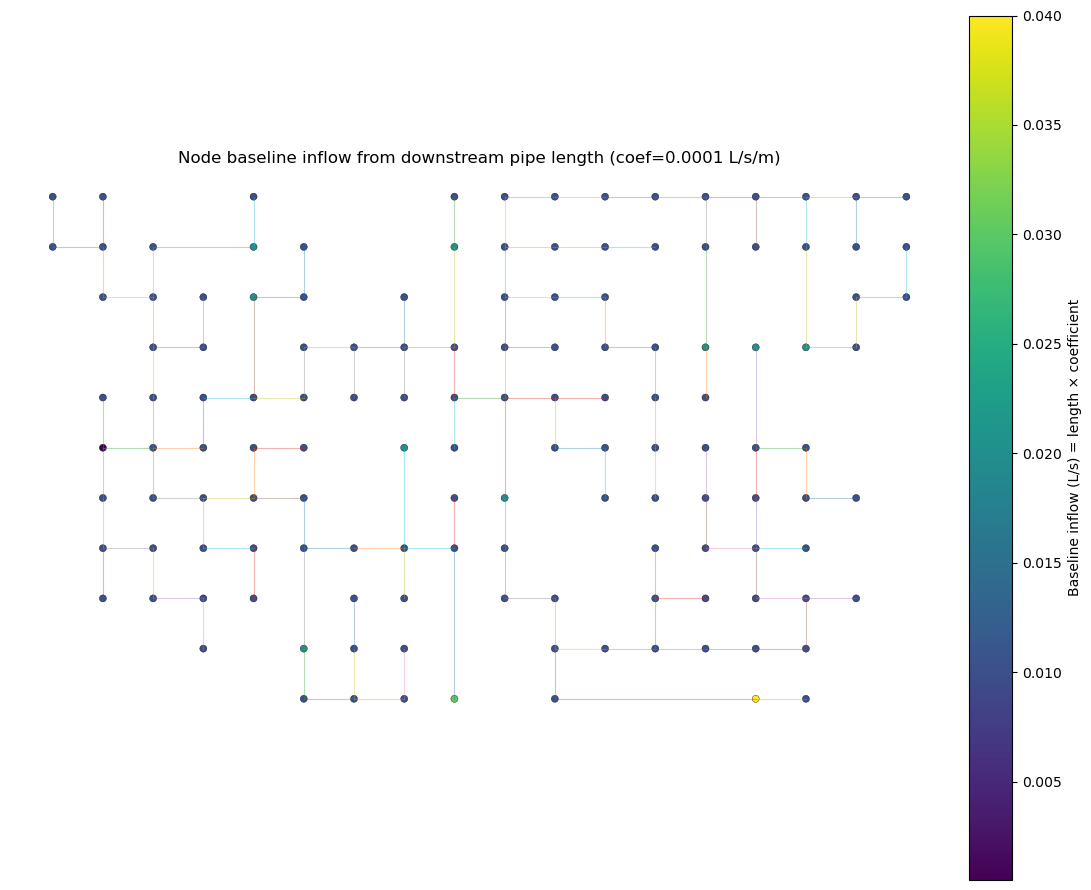

Nodes plotted: 135
Inflow range: 0.0005 to 0.0400 L/s
BWF/DWF + GWI scenario run


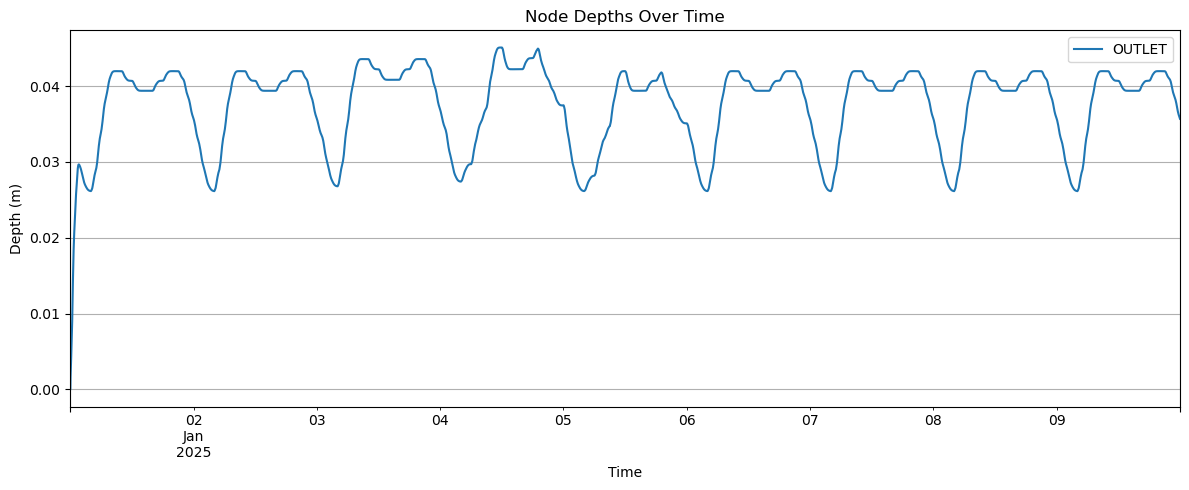

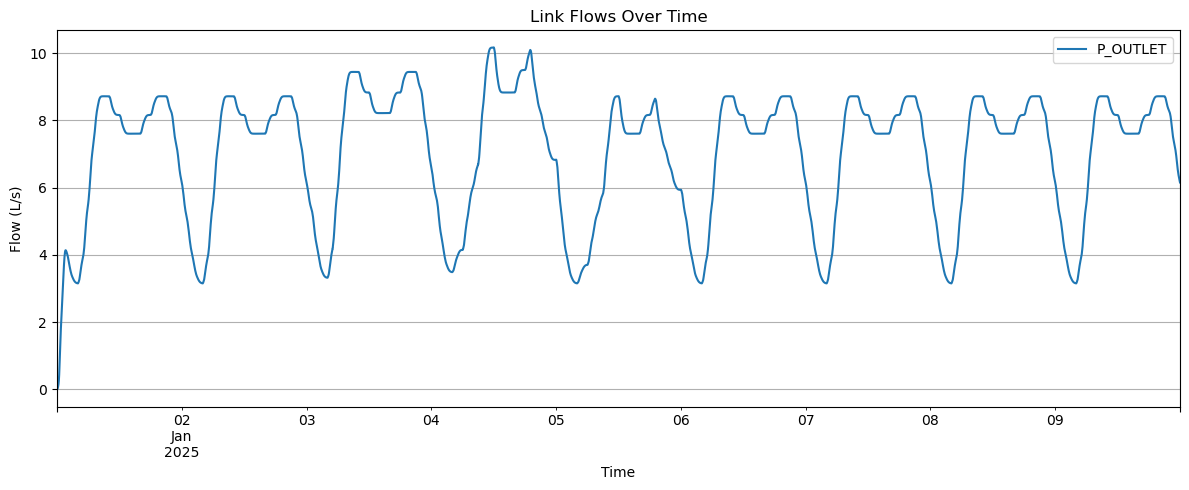

✅ SWMM .inp file updated with subcatchments and saved to: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/scenarios/bwf_gwi_rdii/sewer_model.inp
BWF/DWF + GWI + RDII scenario run


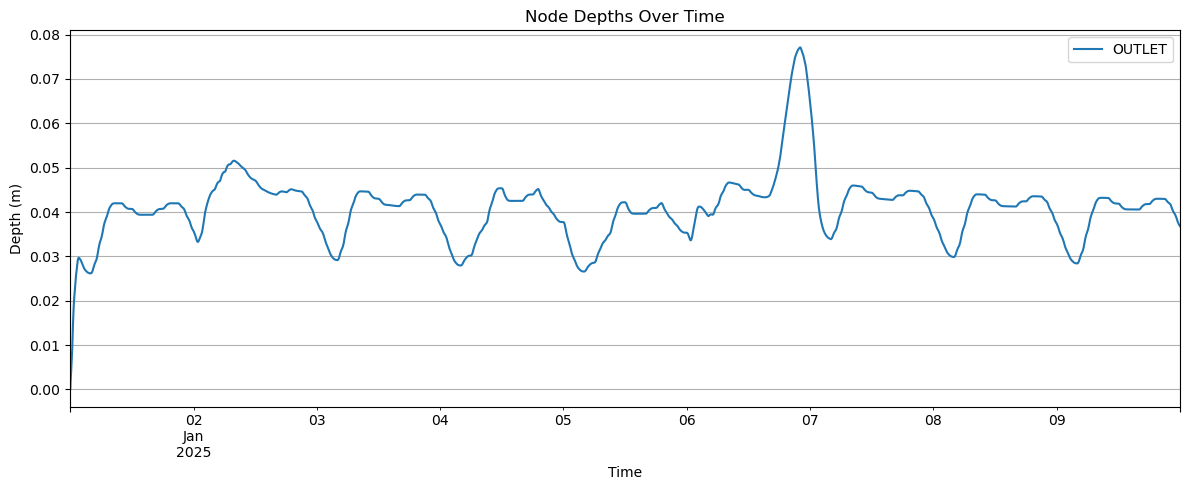

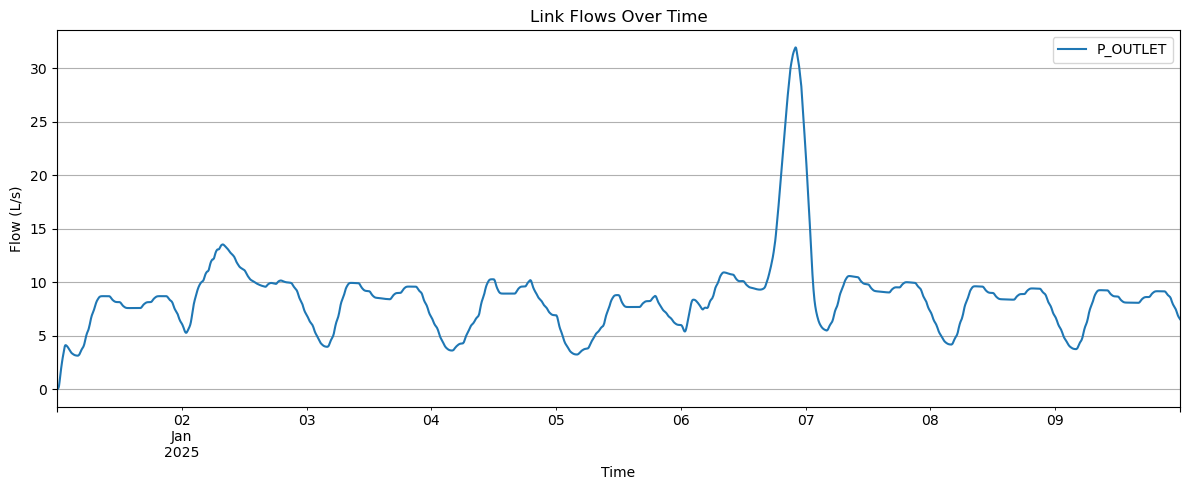

Scenario input: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/scenarios/bwf_gwi_rdii/sewer_model.inp


In [25]:
options = {
    "FLOW_UNITS": "LPS",
    "INFILTRATION": "CURVE_NUMBER",
    "FLOW_ROUTING": "KINWAVE",
    "LINK_OFFSETS": "DEPTH",
    "MIN_SLOPE": "0",
    "ALLOW_PONDING": "NO",
    "SKIP_STEADY_STATE": "NO",
    "START_DATE": "01/01/2025",
    "START_TIME": "00:00:00",
    "REPORT_START_DATE": "01/01/2025",
    "REPORT_START_TIME": "00:00:00",
    "END_DATE": "01/10/2025",
    "END_TIME": "00:00:00",
    "SWEEP_START": "01/01",
    "SWEEP_END": "12/31",
    "DRY_DAYS": "0",
    "REPORT_STEP": "00:15:00",
    "WET_STEP": "00:00:10",
    "DRY_STEP": "00:00:10",
    "ROUTING_STEP": "0:00:10",
    "RULE_STEP": "00:00:00",
    "INERTIAL_DAMPING": "PARTIAL",
    "NORMAL_FLOW_LIMITED": "BOTH",
    "FORCE_MAIN_EQUATION": "D-W",
    "VARIABLE_STEP": "0.75",
    "LENGTHENING_STEP": "0",
    "MIN_SURFAREA": "1.167",
    "MAX_TRIALS": "8",
    "HEAD_TOLERANCE": "0.0015",
    "SYS_FLOW_TOL": "5",
    "LAT_FLOW_TOL": "5",
    "MINIMUM_STEP": "0.5",
    "THREADS": "1",
}
project.export_swmm(options_dict=options)

nodes_to_monitor = ["OUTLET"]
links_to_monitor = ["P_OUTLET"]

hourly = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.4838, 0.8014,
    1.1337, 1.3239, 1.3321, 1.2512, 1.1900, 1.1703,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.3362, 1.3175, 1.1978, 0.9890, 0.7576,
]
daily_vals = [1.0, 1.0, 1.0, 1.0, 1.0, 1.1, 1.2]
monthly_vals = [0.90, 0.95, 1.00, 1.05, 1.10, 1.10, 1.05, 1.00, 0.95, 0.90, 0.90, 0.90]
fairfax_weekend = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.3568, 0.4068,
    0.6068, 0.7068, 0.8014, 1.1337, 1.3239, 1.3321,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.1362, 1.0175, 0.8978, 0.8090, 0.7576,
]

scenario = project.create_run("bwf_gwi_rdii")

# BWF/DWF patterns
scenario.assign_dwf_patterns(
    hourly_id="1",
    hourly_values=hourly,
    daily_id="2",
    daily_values=daily_vals,
    monthly_id="3",
    monthly_values=monthly_vals,
    weekend_id="4",
    weekend_values=fairfax_weekend,
)
print("BWF/DWF pattern scenario run")
depths_bwf_df, flows_bwf_df = scenario.run_swmm(
    monitored_nodes=nodes_to_monitor,
    monitored_links=links_to_monitor,
)

# GWI
scenario.assign_gwi_from_pipe_length(coefficient=0.0001)
st.plot_inflow_from_pipe_length(scenario.swmm_inp_path, coefficient=0.0001)
print("BWF/DWF + GWI scenario run")
depths_gwi_df, flows_gwi_df = scenario.run_swmm(
    monitored_nodes=nodes_to_monitor,
    monitored_links=links_to_monitor,
)

rainfall_data=[
    ('1/2/2025', '00:00', 0.0), ('1/2/2025', '00:30', 0.2205), ('1/2/2025', '01:00', 0.2205),
    ('1/2/2025', '01:30', 0.3855), ('1/2/2025', '02:00', 0.3855), ('1/2/2025', '02:30', 0.447),
    ('1/2/2025', '03:00', 0.447), ('1/2/2025', '03:30', 0.447), ('1/2/2025', '04:00', 0.447),
    ('1/2/2025', '04:30', 0.4155), ('1/2/2025', '05:00', 0.4155), ('1/2/2025', '05:30', 0.3705),
    ('1/2/2025', '06:00', 0.3705), ('1/2/2025', '06:30', 0.3235), ('1/2/2025', '07:00', 0.3235),
    ('1/2/2025', '07:30', 0.2795), ('1/2/2025', '08:00', 0.2795), ('1/2/2025', '08:30', 0.242),
    ('1/2/2025', '09:00', 0.242), ('1/2/2025', '09:30', 0.211), ('1/2/2025', '10:00', 0.211),
    ('1/2/2025', '10:30', 0.186), ('1/2/2025', '11:00', 0.186), ('1/2/2025', '11:30', 0.1655),
    ('1/2/2025', '12:00', 0.1655), ('1/2/2025', '12:30', 0.148), ('1/2/2025', '13:00', 0.148),
    ('1/2/2025', '13:30', 0.133), ('1/2/2025', '14:00', 0.133), ('1/2/2025', '14:30', 0.12),
    ('1/2/2025', '15:00', 0.12), ('1/2/2025', '15:30', 0.1075), ('1/2/2025', '16:00', 0.1075),
    ('1/2/2025', '16:30', 0.0955), ('1/2/2025', '17:00', 0.0955), ('1/2/2025', '17:30', 0.085),
    ('1/2/2025', '18:00', 0.085), ('1/2/2025', '18:30', 0.0745), ('1/2/2025', '19:00', 0.0745),
    ('1/2/2025', '19:30', 0.0655), ('1/2/2025', '20:00', 0.0655), ('1/2/2025', '20:30', 0.0575),
    ('1/2/2025', '21:00', 0.0575), ('1/2/2025', '21:30', 0.0505), ('1/2/2025', '22:00', 0.0505),
    ('1/2/2025', '22:30', 0.045), ('1/2/2025', '23:00', 0.045), ('1/2/2025', '23:30', 0.0405),
    ('1/3/2025', '00:00', 0.0405), ('1/3/2025', '00:30', 0.0365), ('1/3/2025', '01:00', 0.0365),
    ('1/3/2025', '01:30', 0.034), ('1/3/2025', '02:00', 0.034), ('1/3/2025', '02:30', 0.031),
    ('1/3/2025', '03:00', 0.031), ('1/3/2025', '03:30', 0.0295), ('1/3/2025', '04:00', 0.0295),
    ('1/3/2025', '04:30', 0.027), ('1/3/2025', '05:00', 0.027), ('1/3/2025', '05:30', 0.025),
    ('1/3/2025', '06:00', 0.025), ('1/3/2025', '06:30', 0.022), ('1/3/2025', '07:00', 0.022),
    ('1/3/2025', '07:30', 0.0195), ('1/3/2025', '08:00', 0.0195), ('1/3/2025', '08:30', 0.0165),
    ('1/3/2025', '09:00', 0.0165), ('1/3/2025', '09:30', 0.0135), ('1/3/2025', '10:00', 0.0135),
    ('1/3/2025', '10:30', 0.01), ('1/3/2025', '11:00', 0.01), ('1/3/2025', '11:30', 0.0075),
    ('1/3/2025', '12:00', 0.0075), ('1/3/2025', '12:30', 0.005), ('1/3/2025', '13:00', 0.005),
    ('1/3/2025', '13:30', 0.003), ('1/3/2025', '14:00', 0.003), ('1/3/2025', '14:30', 0.002),
    ('1/3/2025', '15:00', 0.002), ('1/3/2025', '15:30', 0.0005), ('1/3/2025', '16:00', 0.0005),
    ('1/3/2025', '16:30', 0.0), ('1/3/2025', '17:00', 0.0), ('1/3/2025', '17:30', 0.0005),
    ('1/3/2025', '18:00', 0.0005), ('1/3/2025', '18:30', 0.0), ('1/3/2025', '19:00', 0.0),
    ('1/3/2025', '19:30', 0.0), ('1/3/2025', '20:00', 0.0), ('1/3/2025', '20:30', 0.0),
    ('1/3/2025', '21:00', 0.0005), ('1/3/2025', '21:30', 0.0005), ('1/3/2025', '22:00', 0.0005),
    ('1/3/2025', '22:30', 0.0005), ('1/3/2025', '23:00', 0.0), ('1/3/2025', '23:30', 0.0),
    ('1/4/2025', '00:00', 0.0), ('1/4/2025', '00:30', 0.0), ('1/4/2025', '01:00', 0.0),
    ('1/6/2025', '00:00', 0.0), ('1/6/2025', '00:30', 0.312), ('1/6/2025', '01:00', 0.32),
    ('1/6/2025', '01:30', 0.33), ('1/6/2025', '02:00', 0.324), ('1/6/2025', '02:30', 0.302),
    ('1/6/2025', '03:00', 0.27), ('1/6/2025', '03:30', 0.238), ('1/6/2025', '04:00', 0.208),
    ('1/6/2025', '04:30', 0.184), ('1/6/2025', '05:00', 0.168), ('1/6/2025', '05:30', 0.154),
    ('1/6/2025', '06:00', 0.148), ('1/6/2025', '06:30', 0.142), ('1/6/2025', '07:00', 0.136),
    ('1/6/2025', '07:30', 0.132), ('1/6/2025', '08:00', 0.128), ('1/6/2025', '08:30', 0.122),
    ('1/6/2025', '09:00', 0.12), ('1/6/2025', '09:30', 0.116), ('1/6/2025', '10:00', 0.114),
    ('1/6/2025', '10:30', 0.116), ('1/6/2025', '11:00', 0.116), ('1/6/2025', '11:30', 0.114),
    ('1/6/2025', '12:00', 0.116), ('1/6/2025', '12:30', 0.112), ('1/6/2025', '13:00', 0.11),
    ('1/6/2025', '13:30', 0.104), ('1/6/2025', '14:00', 0.102), ('1/6/2025', '14:30', 0.1),
    ('1/6/2025', '15:00', 0.11), ('1/6/2025', '15:30', 0.132), ('1/6/2025', '16:00', 0.172),
    ('1/6/2025', '16:30', 0.236), ('1/6/2025', '17:00', 0.324), ('1/6/2025', '17:30', 0.442),
    ('1/6/2025', '18:00', 0.586), ('1/6/2025', '18:30', 0.754), ('1/6/2025', '19:00', 0.93),
    ('1/6/2025', '19:30', 1.11), ('1/6/2025', '20:00', 1.268), ('1/6/2025', '20:30', 1.392),
    ('1/6/2025', '21:00', 1.46), ('1/6/2025', '21:30', 1.456), ('1/6/2025', '22:00', 1.37),
    ('1/6/2025', '22:30', 1.202), ('1/6/2025', '23:00', 0.964), ('1/6/2025', '23:30', 0.694),
    ('1/7/2025', '00:00', 0.44), ('1/7/2025', '00:30', 0.0), ('1/7/2025', '01:00', 0.0),          
]

scenario.add_subcatchment_rdii(
    raingage_id="1",
    raingage_coords=(500, 500),
    timeseries=rainfall_data,
    interval='0:30',
    n_imperv=0.011,
    n_perv=0.15,
    s_imperv=0.0,
    s_perv=0.0,
    pct_zero=0,
    route_to="OUTLET",
    pct_routed="",
    infiltration_params=(50, 0.5, 7, "", ""),
    imperv_pct=5,
    width=100,
    slope=0.005,
    curblen=0,
)
print("BWF/DWF + GWI + RDII scenario run")
depths_rdii_df, flows_rdii_df = scenario.run_swmm(
    monitored_nodes=nodes_to_monitor,
    monitored_links=links_to_monitor,
)

print("Scenario input:", scenario.swmm_inp_path)


## 11. EPA-SWMM Simulation

Run the named scenario. You can create additional scenarios that change only BWF, GWI, or RDII inputs without regenerating the physical network.

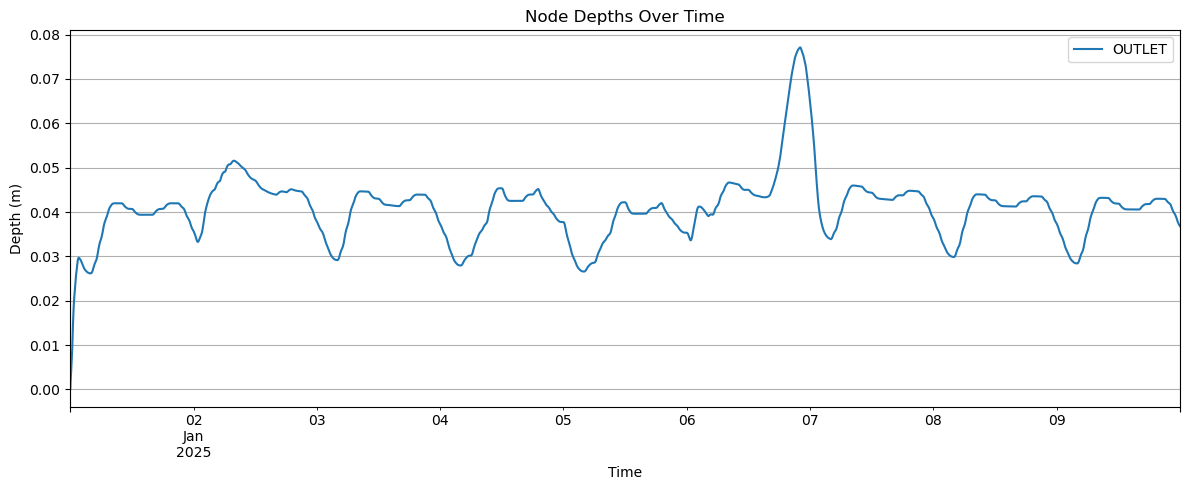

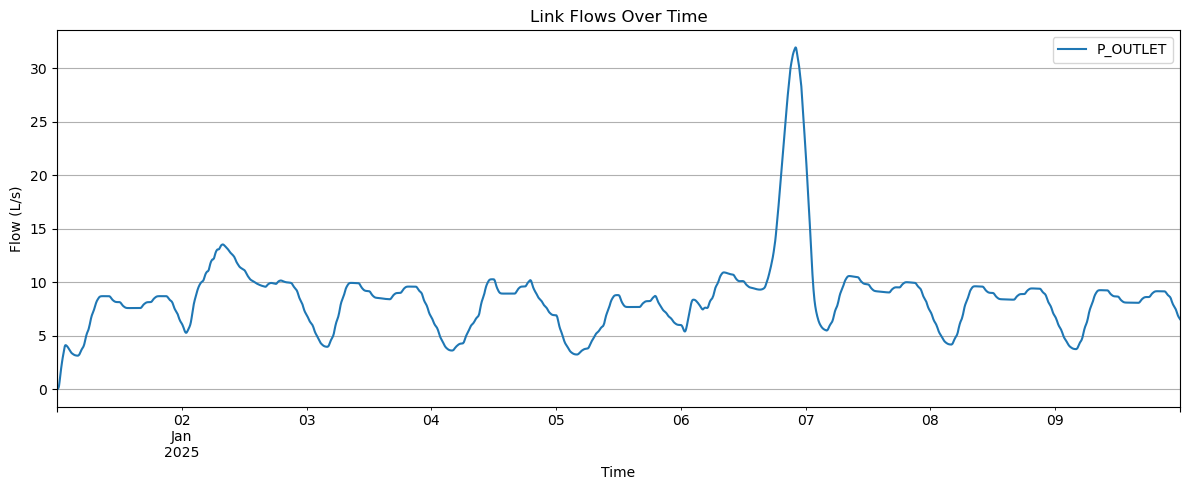

In [26]:
nodes_to_monitor = ["OUTLET"]
links_to_monitor = ["P_OUTLET"]

depths_df, flows_df = scenario.run_swmm(
    monitored_nodes=nodes_to_monitor,
    monitored_links=links_to_monitor,
)

## 12. Flow Output Decomposition

Tracer pollutants are added to the scenario input, flow components are extracted from PySWMM, and the resulting dataset is saved inside the scenario folder.

✅ Tagged inp written (uses CONCEN) -> /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/scenarios/bwf_gwi_rdii/sewer_model.inp


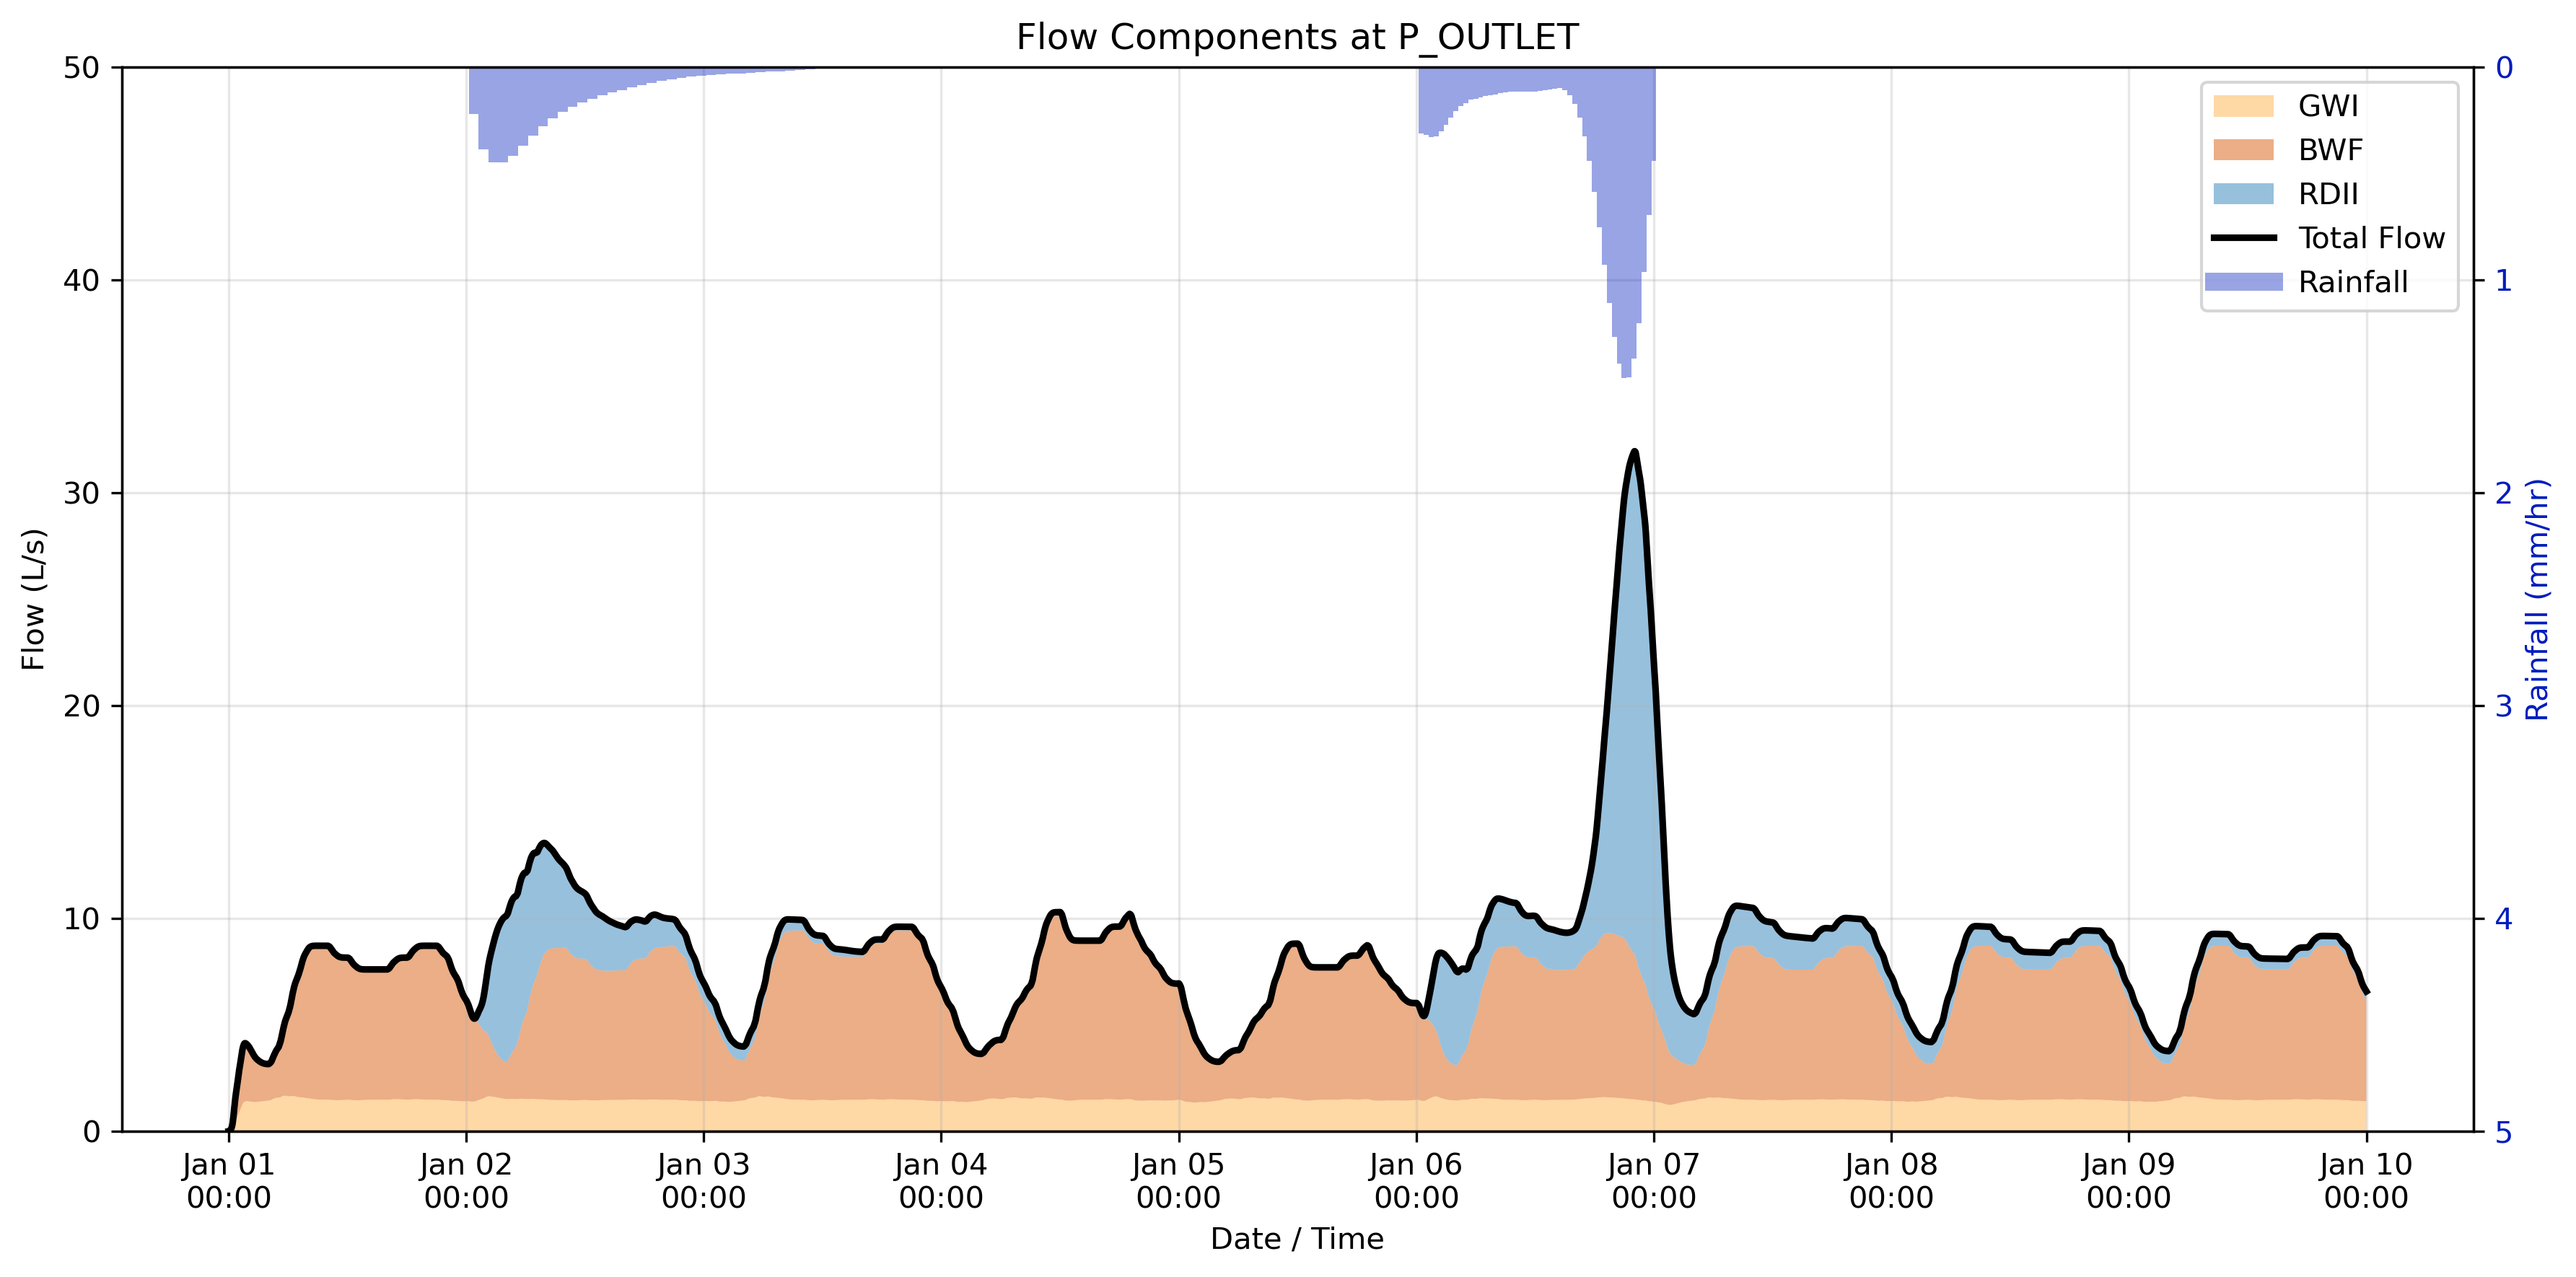

Flow components: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/scenarios/bwf_gwi_rdii/flows.nc
Project metadata: /Users/kevinblanco/Documents/Sewertris/Examples/output_example_1_project/sewertris_project.json


In [27]:
scenario.add_pollutant_tags()
df = scenario.get_flow_components(link_id="P_OUTLET")

fig, ax = st.plot_flow_components_v2(
    df,
    rain=rainfall_data,
    start="2025-01-01 00:00:00",
    end="2025-01-10 00:00:00",
    flow_units="L/s",
    stack_components=True,
    flow_min=0,
    flow_max=50,
    rain_min=0,
    rain_max=5
)

flows_path = scenario.save_flow_components(df)
project.save()
print("Flow components:", flows_path)
print("Project metadata:", project.project_file)

## Bonus: Animate the Workflow as a GIF

`animate_pipeline` turns the artifacts produced above into a single animated GIF that tells the story of the build, in order: the **tetris layout** filling the domain (rising *Completion %*), the **road network**, the **manhole** placement, and finally the **sewer network** drawn pipe-by-pipe (main → secondary → tertiary).

It accepts either the in-memory `project` or a path to the project's output folder (e.g. `sp.animate_pipeline("output_example_1_project")`), so it can be re-run later without rebuilding the network. Tune `pieces_per_frame`, `pipes_per_frame`, `frame_ms`, and `hold_ms` to control pacing and file size.

In [ ]:
# Bonus: animate the full workflow as a single GIF.
# Reads the artifacts already written by the steps above (layout, roads, manholes,
# pipes) and renders one GIF in order:
#   tetris completion  ->  road network  ->  manholes  ->  sewer network
gif_path = st.animate_pipeline(
    project,                          # or a folder path, e.g. project.output_dir
    out_path=project.path("pipeline.gif"),
)
print("Animation saved to:", gif_path)

from IPython.display import Image as IPyImage
IPyImage(filename=str(gif_path))